In [ ]:
import pandas as pd
from pathlib import Path
import mdtraj as md
import gemmi
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from folddof.io import savebb2pdb

import subprocess
import yaml
import shutil
from io import StringIO
import umap
from tqdm import trange, tqdm
import sys
import pickle

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns


cmap = sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)


def get_2d_color(a, b):
    import matplotlib.colors as mcolors
    colors = np.zeros((len(a), 3))
    colors[:, 0] = a
    colors[:, 2] = b
    colors[:, 1] = 0
    return colors


def get_result_csv(run_dir, source_dir, name: str='result', metric: str = 'mad', threads=30, tm_score_cutoff_for_clustering: float = 0.6):
    root_dir_name = run_dir.parent.parent.parent.name
    
    with open(f'{run_dir}/config.yaml', 'r') as f:
        conf = yaml.load(f, Loader=yaml.FullLoader)
    if not Path(f'{run_dir}/Single_PDB_Metrics.csv').exists():
        return
    pdb_metrics = pd.read_csv(f'{run_dir}/Single_PDB_Metrics.csv')
    summary_tmscore = pd.read_csv(f'{run_dir}/summary_tmscore.csv')#.dropna()
    summary_tmscore = summary_tmscore[~summary_tmscore['PDB File'].str.startswith('==>')].reset_index(drop=True).rename(columns={'PDB File': 'pdb_path'})
    summary_tmscore['Max TM-score'] = summary_tmscore['Max TM-score'].fillna(0)
    summary_tmscore['Max TM-score (previous)'] = summary_tmscore['Max TM-score (previous)'].fillna(0)
    assert not summary_tmscore.isna().any().any()

    summary_tmscore.Designable = summary_tmscore.Designable.astype(int).astype(bool)
    assert pdb_metrics.shape[0] == summary_tmscore.shape[0], (1, run_dir)
    pdb_metrics = pdb_metrics.merge(summary_tmscore)
    assert pdb_metrics.shape[0] == summary_tmscore.shape[0], (2, run_dir)
    pdb_metrics.pdb_path = pdb_metrics.pdb_path.apply(lambda x: x[x.index('inference'):])

    if 'min_mad' not in pdb_metrics.columns: pdb_metrics['min_mad'] = pdb_metrics['min_rmsd']

    pdb_metrics['Designable'] = pdb_metrics[f'min_{metric}'].lt(2)

    fraction = pdb_metrics.Designable.sum()/pdb_metrics.shape[0]
    fraction_by_group = pdb_metrics.groupby('length').Designable.sum()/pdb_metrics.groupby('length').size()
    designability = dict(fraction=fraction, scMAD_mean=pdb_metrics[f'min_{metric}'].mean(), scMAD_std=pdb_metrics[f'min_{metric}'].std(ddof=0),
                         fraction_mean=fraction_by_group.mean(), fraction_std=fraction_by_group.std(ddof=0))
    designable_pdb_metrics = pdb_metrics[pdb_metrics.Designable]
    focus_cols = ['helix_percent',
       'strand_percent', 'coil_percent', 'non_coil_percent',
       'radius_of_gyration', 'ca_ca_deviation', 'ca_ca_valid_percent',
       'num_ca_ca_clashes', 'Max TM-score']
    designable_stat = designable_pdb_metrics[focus_cols].add_prefix('designable.mean.').mean().to_dict()
    designable_stat['designanle.fraction_lt_0.5.Max TM-score'] = designable_pdb_metrics['Max TM-score'].lt(0.5).sum()/designable_pdb_metrics.shape[0]
    all_stat = pdb_metrics[focus_cols].add_prefix('mean.').mean().to_dict()
    all_stat['fraction_lt_0.5.Max TM-score'] = pdb_metrics['Max TM-score'].lt(0.5).sum()/pdb_metrics.shape[0]

    ret_stat = designability | designable_stat | all_stat

    all_sample_path = f'tmp_dir_for_search/{root_dir_name}/pdb/'
    tmp = f'tmp_dir_for_search/{root_dir_name}/tmp'
    Path(all_sample_path).mkdir(parents=True, exist_ok=True)
    Path(tmp).mkdir(parents=True, exist_ok=True)
    output_file = f'tmp_dir_for_search/{name}.full.txt'
    if not Path(output_file).exists():
        shutil.rmtree(f'tmp_dir_for_search/{root_dir_name}/pdb')
        Path(f'tmp_dir_for_search/{root_dir_name}/pdb').mkdir(parents=True, exist_ok=True)
        for idx, file in enumerate((f'{source_dir}/' + pdb_metrics.pdb_path)): # [pdb_metrics.Designable]
            Path(f'tmp_dir_for_search/{root_dir_name}/pdb/{idx}.pdb').symlink_to(file)

        p = subprocess.run(f"foldseek easy-search {all_sample_path} {all_sample_path} {output_file} {tmp} --alignment-type 1 --exhaustive-search 1 --tmscore-threshold 0.0 --format-mode 4 -e inf --max-seqs 10000000000 --threads {threads} --format-output query,target,alntmscore,lddt,evalue",
                shell=True, capture_output=True)
        assert p.returncode == 0, p.stderr
    else:
        pass
    tm_matrix = np.zeros((pdb_metrics.shape[0],)*2) # pdb_metrics.Designable.sum()
    for record in pd.read_csv(output_file, sep='\t').itertuples():
        tm_matrix[record.query, record.target] = record.evalue
    tm_matrix = (tm_matrix + tm_matrix.T)/2 # np.maximum(tm_matrix, tm_matrix.T)
    designable_tm_matrix = tm_matrix[np.ix_(*np.where(pdb_metrics.Designable)*2)]
    ret_stat['designable.diversity_TM'] = np.mean([designable_tm_matrix[(slice(index.min(), index.max()+1), )*2][np.triu_indices(index.shape[0], k=1) if index.shape[0] > 1 else None].mean() for index in pdb_metrics[pdb_metrics.Designable].reset_index(drop=True).groupby('length').indices.values()])

    clusters = AgglomerativeClustering(distance_threshold=1-tm_score_cutoff_for_clustering, n_clusters=None, metric='precomputed', linkage='average').fit(1-tm_matrix).labels_
    designable_cluster_label, designable_cluster_count = np.unique(clusters[pdb_metrics.Designable], return_counts=True)
    ret_stat['designable.diversity_Cluster'] = designable_cluster_label.shape[0]/pdb_metrics.Designable.sum()

    """
    pdb_metrics['cluster_id'] = -1
    pdb_metrics.loc[pdb_metrics.index[pdb_metrics.Designable], 'cluster_id'] = clusters
    """
    pdb_metrics['cluster_id'] = clusters

    ret_stat['num_timesteps'] = conf['inference']['interpolant']['sampling']['num_timesteps']
    pdb_metrics['num_timesteps'] = ret_stat['num_timesteps']
    ret_stat['name'] = name
    pdb_metrics['name'] = name

    return ret_stat, pdb_metrics, tm_matrix, clusters


map_dict = {'original.0.0': r'$\text{FrameFlow}$',
            'global_pep.0.0': r'$\text{FrameFlow}_{\text{Pep}}$', 
            'global_pep.0.1': r'$\text{FrameFlow}_{\text{Pep}}^{\text{Rel}}$',
            }


def pipeline(stat_list, pdb_metrics_list, meta_list, focus_length = (61, 60)):
    stat_list = pd.DataFrame(stat_list)
    stat_list['ckpt'] = stat_list['name'].apply(lambda x: x.split('.')[3])
    stat_list['Model'] = stat_list['name'].apply(lambda x: '.'.join(x.split('.')[:2])).map(map_dict)
    stat_list['run'] = stat_list.name.apply(lambda x: x.split('.')[-1]) 
    
    #pdb_metrics_list_ = pdb_metrics_list
    pdb_metrics_list = pd.concat(pdb_metrics_list, sort=False, ignore_index=True)
    pdb_metrics_list['ckpt'] = pdb_metrics_list['name'].apply(lambda x: x.split('.')[3])
    pdb_metrics_list['Model'] = pdb_metrics_list['name'].apply(lambda x: '.'.join(x.split('.')[:2])).map(map_dict)
    pdb_metrics_list['run'] = pdb_metrics_list.name.apply(lambda x: x.split('.')[-1])

    meta_list = pd.DataFrame(meta_list)

    focus_ckpt = meta_list.groupby(by=['ckpt','sample_min_length']).num_timesteps.agg(set).apply(sorted).apply(tuple).apply(lambda x: (x == (10, 20, 50, 100, 200, 300, 400, 500)) or (x == (100, 200, 300, 400, 500))).reset_index().query('num_timesteps == True')[['ckpt', 'sample_min_length']]

    focsu_records = stat_list.merge(focus_ckpt[['ckpt']].drop_duplicates()).merge(meta_list[meta_list.sample_min_length.isin(focus_length)][['ckpt', 'num_timesteps', 'run']])

    focus_pdb_metrics_list = pdb_metrics_list.merge(focus_ckpt[['ckpt']].drop_duplicates()).merge(meta_list[meta_list.sample_min_length.isin(focus_length)][['ckpt', 'num_timesteps', 'run']])
    focus_pdb_metrics_list['Designable_TM'] = focus_pdb_metrics_list.max_tm_score > 0.9

    focus_cols = ['min_mad', 'max_tm_score', 'helix_percent', 'strand_percent', 'Designable', 'Designable_TM', 'Max TM-score']
    clustered_stat_list = focus_pdb_metrics_list.groupby(by=['name', 'cluster_id'])[focus_cols].mean().reset_index().groupby(by=['name'])[focus_cols].mean().reset_index()
    clustered_stat_list['num_timesteps'] = clustered_stat_list['name'].apply(lambda x: int(x.split('.')[4]))
    clustered_stat_list['ckpt'] = clustered_stat_list['name'].apply(lambda x: x.split('.')[3])
    clustered_stat_list = clustered_stat_list.merge((focus_pdb_metrics_list[focus_pdb_metrics_list.Designable].groupby(by=['name', 'cluster_id'])[focus_cols].mean().reset_index().groupby(by=['name']).cluster_id.agg(set).apply(len)/ \
                                                    focus_pdb_metrics_list[focus_pdb_metrics_list.Designable].groupby(by=['name']).size()).reset_index().rename(columns={0: 'designable.diversity_Cluster'}))
    clustered_stat_list = clustered_stat_list.merge(
        focus_pdb_metrics_list[focus_pdb_metrics_list.Designable].groupby(by=['name', 'cluster_id'])[focus_cols].mean().reset_index().groupby(by=['name'])[focus_cols].mean().reset_index()[['name', 'helix_percent', 'strand_percent']].rename(columns={'helix_percent': 'designable.helix_percent', 'strand_percent': 'designable.strand_percent'}))
    
    clustered_stat_list = clustered_stat_list.merge(
        focus_pdb_metrics_list[focus_pdb_metrics_list.Designable].groupby(by=['name', 'cluster_id'])[focus_cols].mean().reset_index().groupby(by=['name'])[focus_cols].mean().reset_index()[['name', 'Max TM-score']].rename(columns={'Max TM-score': 'designable.mean.Max TM-score'}))
    
    clustered_stat_list['Model'] = clustered_stat_list['name'].apply(lambda x: '.'.join(x.split('.')[:3])).map(map_dict)

    return focsu_records, focus_pdb_metrics_list, clustered_stat_list


def ramalyze_unit(file: str, bb: bool = True, overwrite_three_letter_seq = None):
    try:
        from mmtbx.validation import ramalyze, omegalyze
        import mmtbx.model
        from libtbx.utils import null_out
        import iotbx
    except Exception:
        print('please install cctbx and chem_data: conda install -c conda-forge cctbx-base; conda install chem_data::chem_data')
    
    pdb_inp = iotbx.pdb.input(file_name=file)
    model = mmtbx.model.manager(model_input=pdb_inp)
    if overwrite_three_letter_seq is not None:
        # model.set_sequences([iotbx.bioinformatics.sequence(overwrite_seq)])
        # ref: https://github.com/copilot/c/f1f3e7e5-9859-4d17-8046-71625902f64d
        ph = model.get_hierarchy()
        for md in ph.models():
            for chain in md.chains():
                for rg, new_name in zip(chain.residue_groups(), overwrite_three_letter_seq):
                    for ag in rg.atom_groups():
                        ag.resname = new_name
        #ph.atoms().reset_i_seq()
    ret = dict(file=file)
    if bb:
        rama_result = ramalyze.ramalyze(model.get_hierarchy())
        omega_result = omegalyze.omegalyze(model.get_hierarchy())
        # https://github.com/cctbx/cctbx_project/blob/master/mmtbx/model/statistics.py#L212
        n_proline         = omega_result.n_proline()
        n_general         = omega_result.n_general()
        n_cis_proline     = omega_result.n_cis_proline()
        n_cis_general     = omega_result.n_cis_general()
        n_twisted_proline = omega_result.n_twisted_proline()
        n_twisted_general = omega_result.n_twisted_general()
        cis_general       = 0
        twisted_general   = 0
        cis_proline       = 0
        twisted_proline   = 0
        if(n_proline != 0):
            cis_proline     = n_cis_proline    /n_proline
            twisted_proline = n_twisted_proline/n_proline
        if(n_general != 0):
            cis_general     = n_cis_general    /n_general
            twisted_general = n_twisted_general/n_general

        ret = ret | dict(
            rama_percent_favored=rama_result.get_favored_count_and_fraction()[1], 
            rama_percent_allowed=rama_result.get_allowed_count_and_fraction()[1], 
            rama_percent_outliers=rama_result.get_outliers_count_and_fraction()[1], 
            omega_cis_general=cis_general, omega_twisted_general=twisted_general, omega_cis_proline=cis_proline, omega_twisted_proline=twisted_proline)

    return ret


def get_ss_content(pdb_path):
    traj = md.load(pdb_path)
    pdb_ss = md.compute_dssp(traj, simplified=True)
    pdb_coil_percent = np.mean(pdb_ss == 'C')
    pdb_helix_percent = np.mean(pdb_ss == 'H')
    pdb_strand_percent = np.mean(pdb_ss == 'E')
    return pdb_helix_percent, pdb_strand_percent, pdb_coil_percent

In [ ]:
def preprocess(root_dir, source_dir, threads=64):
    stat_list, pdb_metrics_list, tm_matrix_list, clusters_list = [], [], [], []
    meta_list = []
    root_dir = Path(root_dir)
    for ckpt_folder in root_dir.iterdir():
        for run_dir in (ckpt_folder/'unconditional').iterdir():
            if run_dir.is_file(): continue
            if not run_dir.name.startswith('run_'): continue
            with Path(f'{run_dir}/config.yaml').open('r') as f:
                conf = yaml.load(f, Loader=yaml.FullLoader)
            meta = dict(bb_repr=conf['bb_repr'],
                        rot_repr_is_q=conf['rot_repr_is_q'],
                        relative_pep_trans=conf['model']['relative_pep_trans'],
                        relative_pep_trans_on_ipa_update=conf['model']['relative_pep_trans_on_ipa_update'],
                        override_pep_iso=conf['model']['override_pep_iso'],
                        keep_true_pep_iso=conf['interpolant']['trans']['keep_true_pep_iso'],
                        slerp=conf['interpolant']['rots']['slerp'],
                        inference_slerp=conf['inference']['interpolant']['rots']['slerp'],
                        ckpt=ckpt_folder.name,
                        num_timesteps=conf['inference']['interpolant']['sampling']['num_timesteps'],
                        sample_min_length=conf['inference']['samples']['min_length'],
                        sample_max_length=conf['inference']['samples']['max_length'],
                        run=run_dir.name,)
            try:
                ret_stat, pdb_metrics, tm_matrix, clusters = get_result_csv(
                    run_dir=run_dir, source_dir=source_dir, threads=threads,
                    name=f'{meta["bb_repr"]}.{int(meta["relative_pep_trans"])}.{int(meta["relative_pep_trans_on_ipa_update"])}.{int(meta["override_pep_iso"])}.{meta["ckpt"]}.{meta["num_timesteps"]}.{run_dir.name}')
            except Exception as e:
                print(run_dir, e)
                continue
            stat_list.append(ret_stat)
            pdb_metrics_list.append(pdb_metrics)
            tm_matrix_list.append(tm_matrix)
            clusters_list.append(clusters)
            meta_list.append(meta)
    #with open(f'{ROOT_DIR}.pickle', 'wb') as handle:
    #   pickle.dump((stat_list, pdb_metrics_list, tm_matrix_list, clusters_list, meta_list), handle)
    return stat_list, pdb_metrics_list, tm_matrix_list, clusters_list, meta_list

In [3]:
df = pd.read_csv('../metadata/scope_metadata.clean.csv', keep_default_na=False)
ref_df = df[df.seq_len.le(128) & df.seq_len.ge(60)].reset_index(drop=True)

In [ ]:
focsu_records, clustered_stat_list = [], []
focus_pdb_metrics_list = []
focus_length = (60, 61) # (130,131)
THREADS = 64
SOURCE_DIR = '/home/your_name/tools/PepFrameFlow'
ROOT_DIR = [
    f'{SOURCE_DIR}/inference_outputs/hallucination_scope/frameflow_dir', 
    f'{SOURCE_DIR}/inference_outputs/hallucination_scope/frameflow_pep_dir', 
    f'{SOURCE_DIR}/inference_outputs/hallucination_scope/frameflow_pep_rel_dir']


for root_dir in ROOT_DIR:
    stat_list, pdb_metrics_list, tm_matrix_list, clusters_list, meta_list = preprocess(root_dir, source_dir=SOURCE_DIR, threads=THREADS)
    ret = pipeline(stat_list, pdb_metrics_list, meta_list, focus_length=focus_length)
    focsu_records.append(ret[0])
    focus_pdb_metrics_list.append(ret[1])
    clustered_stat_list.append(ret[2])
    

focsu_records = pd.concat(focsu_records, ignore_index=True, sort=False)
clustered_stat_list = pd.concat(clustered_stat_list, ignore_index=True, sort=False)
focus_pdb_metrics_list = pd.concat(focus_pdb_metrics_list, ignore_index=True, sort=False)

In [ ]:
focsu_records.ckpt = focsu_records.Model + ' ' + focsu_records.ckpt
clustered_stat_list.ckpt = clustered_stat_list.Model + ' ' + clustered_stat_list.ckpt
focus_pdb_metrics_list.ckpt = focus_pdb_metrics_list.Model + ' ' + focus_pdb_metrics_list.ckpt
focus_pdb_metrics_list['length_merge'] = focus_pdb_metrics_list.length.apply(lambda x: int(x/8)*8 if focus_length == (60, 61) else int(x/20)*20)

In [ ]:
all_result_origin_list = []
for all_result_origin_path in focus_pdb_metrics_list.pdb_path.apply(lambda x: Path(x).parent.parent.parent).drop_duplicates().apply(lambda x: (SOURCE_DIR/x/'All_Results_Origin.csv')):
    all_result_origin = pd.read_csv(all_result_origin_path)
    all_result_origin.Model_sample_pdb_path = all_result_origin.Model_sample_pdb_path.str.replace(SOURCE_DIR, '')
    all_result_origin = all_result_origin.merge(all_result_origin.groupby('Model_sample_pdb_path').rmsd.min().reset_index().rename(columns={'rmsd': 'min_rmsd'}))
    all_result_origin_list.append(all_result_origin)
all_result_origin_list = pd.concat(all_result_origin_list, sort=False, ignore_index=True)
focus_result_origin_list = all_result_origin_list[(all_result_origin_list.mad==all_result_origin_list.min_mad)][['Model_sample_pdb_path', 'sequence', 'min_rmsd', 'rmsd', 'tm_score']].rename(columns={'Model_sample_pdb_path': 'pdb_path'})

In [7]:
focus_pdb_metrics_list = focus_pdb_metrics_list.merge(focus_result_origin_list)
focus_pdb_metrics_list['Designable_rmsd'] = focus_pdb_metrics_list.min_rmsd < 2.0

In [8]:
ramalyze_results = focus_pdb_metrics_list.apply(lambda x: ramalyze_unit(
    f'{SOURCE_DIR}/{x["pdb_path"]}', 
    overwrite_three_letter_seq=gemmi.expand_one_letter_sequence(x["sequence"], gemmi.ResidueKind.AA)),
axis=1)

focus_pdb_metrics_list = pd.concat((focus_pdb_metrics_list, pd.DataFrame(ramalyze_results.tolist()).drop(columns=['file'])), axis=1)

In [9]:
loc_geo_stat = focus_pdb_metrics_list.groupby(['name','num_timesteps', 'Model'], sort=False)[['ca_ca_valid_percent', 'ca_ca_deviation', 'num_ca_ca_clashes', 'radius_of_gyration', 'rama_percent_favored', 'rama_percent_allowed', 'rama_percent_outliers', 'omega_cis_general', 'omega_twisted_general', 'omega_cis_proline', 'omega_twisted_proline']].mean().reset_index()

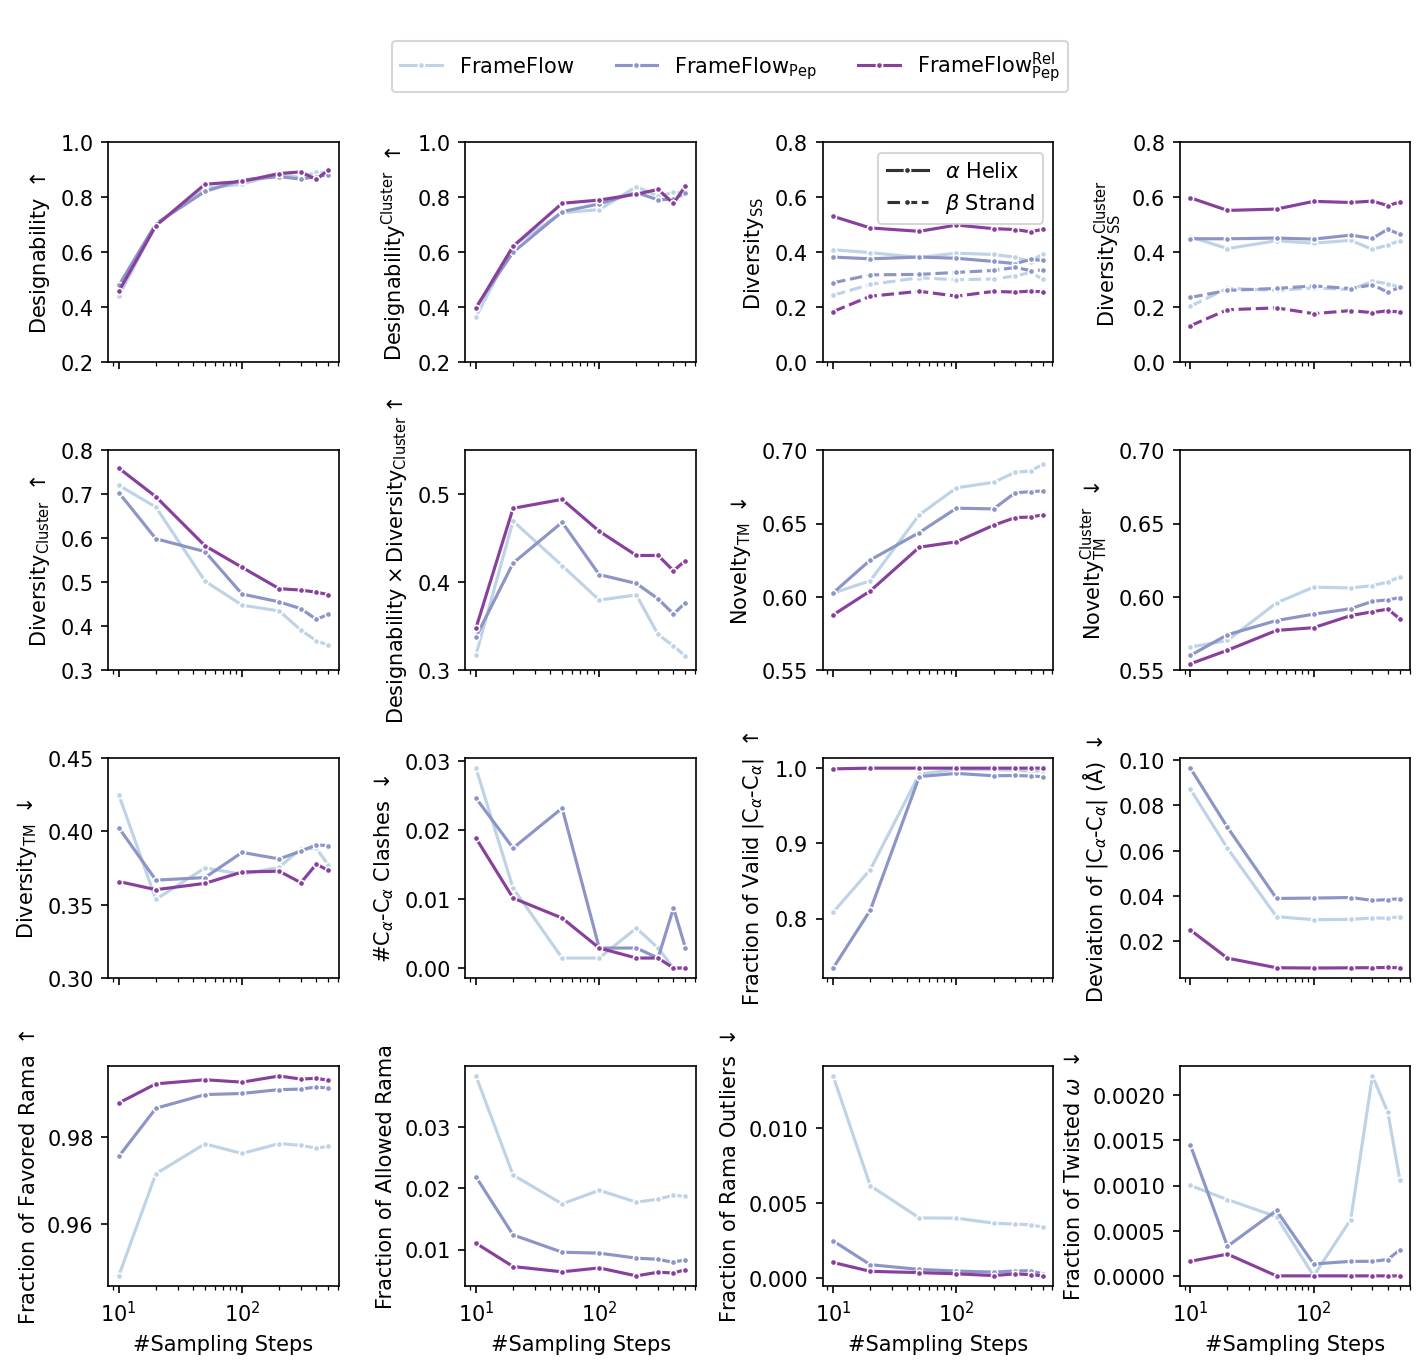

In [10]:
fig, ax = plt.subplots(ncols=4, nrows=4, sharex=True, figsize=(14*0.8,5.5*0.9*2), dpi=150)


g = sns.lineplot(data=focsu_records, x='num_timesteps', y='fraction', hue='Model', marker='o', linewidth=1.5, markersize=3, palette='BuPu', ax=ax[0, 0], legend=True)
g.set_ylim(0.2, 1)
g.set_xscale('log')
g.set_ylabel(r'Designability $\uparrow$')
g.set_xlabel('#Sampling Steps')

g = sns.lineplot(data=clustered_stat_list, x='num_timesteps', y='Designable', hue='Model', marker='o', linewidth=1.5, markersize=3, palette='BuPu', ax=ax[0, 1], legend=False)
g.set_ylim(0.2, 1)
g.set_xscale('log')
g.set_ylabel(r'$\text{Designability}^{\text{Cluster}}$ $\uparrow$')
g.set_xlabel('#Sampling Steps')

g = sns.lineplot(data=focsu_records, x='num_timesteps', y='designable.diversity_Cluster', hue='Model', marker='o', linewidth=1.5, markersize=3, palette='BuPu', ax=ax[1, 0], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'$\text{Diversity}_{\text{Cluster}}$ $\uparrow$')
g.set_ylim(.3,.8)

g = sns.lineplot(data=focsu_records, x='num_timesteps', y='designable.mean.Max TM-score', hue='Model', marker='o', linewidth=1.5, markersize=3, palette='BuPu', ax=ax[1, 2], legend=False)
g.set_xscale('log')
g.set_xlabel('#Total Sampling Steps')
g.set_ylabel(r'$\text{Novelty}_{\text{TM}}$ $\downarrow$')
g.set_ylim(0.55, 0.7)

ss_df = pd.concat((focsu_records[['num_timesteps', 'designable.mean.helix_percent', 'Model']].rename(columns={'designable.mean.helix_percent': 'ss_content'}), focsu_records[['num_timesteps', 'designable.mean.strand_percent', 'Model']].rename(columns={'designable.mean.strand_percent': 'ss_content'})), sort=False, ignore_index=True)
ss_df['ss_type'] = [r'$\alpha$ Helix'] * focsu_records.shape[0] + [r'$\beta$ Strand'] * focsu_records.shape[0]
g = sns.lineplot(
    data=ss_df,
    x='num_timesteps',
    y='ss_content',
    hue='Model', 
    style='ss_type',
    marker='o', 
    linewidth=1.5, markersize=3, palette='BuPu', ax=ax[0, 2], legend=True)
g.set_ylim(0,.8)
handles, labels = g.get_legend_handles_labels()
handles = handles[-2:]
labels = labels[-2:]
g.legend(handles, labels)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'$\text{Diversity}_{\text{SS}}$')

c_ss_df = pd.concat((clustered_stat_list[['num_timesteps', 'designable.helix_percent', 'Model']].rename(columns={'designable.helix_percent': 'ss_content'}), clustered_stat_list[['num_timesteps', 'designable.strand_percent', 'Model']].rename(columns={'designable.strand_percent': 'ss_content'})), sort=False, ignore_index=True)
c_ss_df['ss_type'] = [r'$\alpha$ Helix'] * clustered_stat_list.shape[0] + [r'$\beta$ Strand'] * clustered_stat_list.shape[0]
g = sns.lineplot(
    data=c_ss_df,
    x='num_timesteps',
    y='ss_content',
    hue='Model',
    style='ss_type', 
    marker='o', 
    linewidth=1.5, markersize=3, palette='BuPu', ax=ax[0, 3], legend=False)
g.set_ylim(0,.8)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'$\text{Diversity}_{\text{SS}}^{\text{Cluster}}$')


g = sns.lineplot(ax=ax[1, 1], x=focsu_records['num_timesteps'], y=focsu_records['fraction']*focsu_records['designable.diversity_Cluster'], hue=focsu_records['ckpt'], marker='o', linewidth=1.5, markersize=3, palette='BuPu', legend=False)
g.set_xscale('log')
g.set_ylim(0.3, 0.55)
g.set_ylabel(r'$\text{Designability}\times \text{Diversity}_{\text{Cluster}} \uparrow$')
g.set_xlabel('#Sampling Steps')

g = sns.lineplot(data=clustered_stat_list, x='num_timesteps', y='designable.mean.Max TM-score', hue='ckpt', marker='o', linewidth=1.5, markersize=3, palette='BuPu', ax=ax[1, 3], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'$\text{Novelty}_{\text{TM}}^{\text{Cluster}}$ $\downarrow$')
g.set_ylim(0.55, 0.7)


g = sns.lineplot(data=focsu_records, x='num_timesteps', y='designable.diversity_TM', hue='Model', marker='o', linewidth=1.5, markersize=3, palette='BuPu', ax=ax[2, 0], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'$\text{Diversity}_{\text{TM}}$ $\downarrow$')
g.set_ylim(.3,.45)

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='ca_ca_deviation', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[2, 3], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'Deviation of $|\mathrm{C}_{\alpha}\text{-}\mathrm{C}_{\alpha}|$ (Å) $\downarrow$')

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='ca_ca_valid_percent', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[2, 2], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'Fraction of Valid $|\mathrm{C}_{\alpha}\text{-}\mathrm{C}_{\alpha}|$ $\uparrow$')

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='num_ca_ca_clashes', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[2, 1], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'#$\mathrm{C}_{\alpha}\text{-}\mathrm{C}_{\alpha}$ Clashes $\downarrow$')

# 'rama_percent_favored', 'rama_percent_allowed', 'rama_percent_outliers', 'omega_cis_general', 'omega_twisted_general', 'omega_cis_proline', 'omega_twisted_proline'

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='rama_percent_favored', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[3, 0], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'Fraction of Favored Rama $\uparrow$')

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='rama_percent_allowed', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[3, 1], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'Fraction of Allowed Rama')

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='rama_percent_outliers', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[3, 2], legend=False)
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'Fraction of Rama Outliers $\downarrow$')

g = sns.lineplot(data=loc_geo_stat,
            x='num_timesteps', y='omega_twisted_proline', hue='Model', palette='BuPu', marker='o', linewidth=1.5, markersize=3, ax=ax[3, 3], legend=False, )#linestyle='--')
g.set_xscale('log')
g.set_xlabel('#Sampling Steps')
g.set_ylabel(r'Fraction of Twisted $\omega$ $\downarrow$')
#g.set_yscale('log')


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.275,0.932), ncols=7)
ax[0,0].get_legend().remove()

plt.subplots_adjust(wspace=0.55, hspace=0.4)
plt.show()

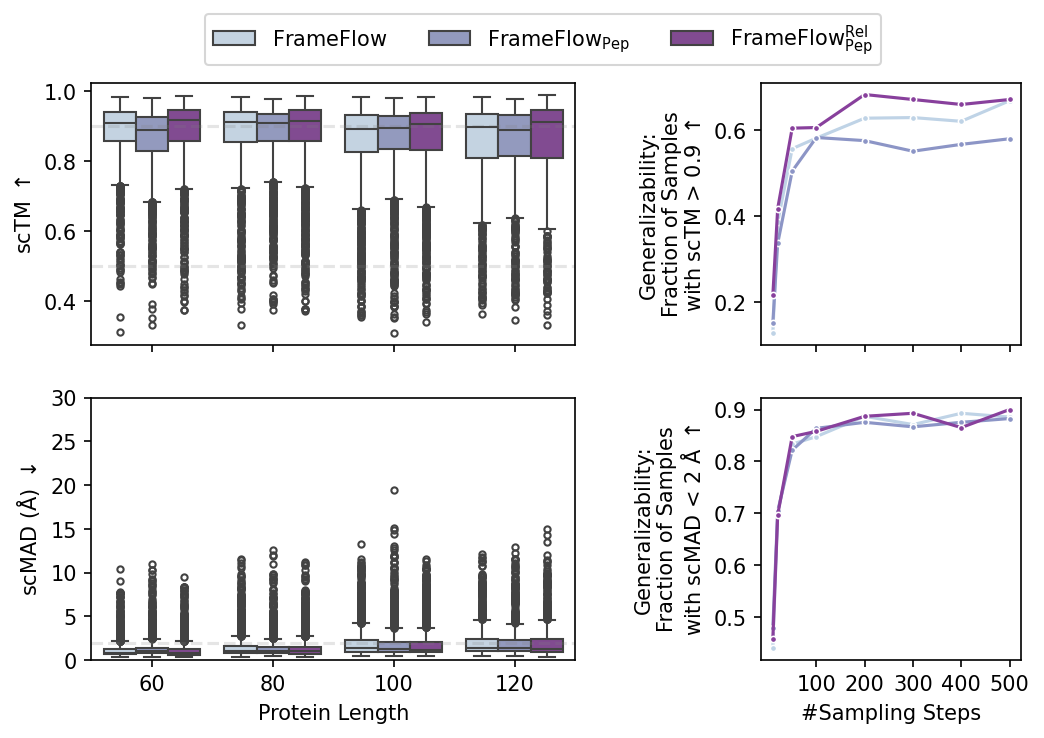

In [11]:
fig, ax = plt.subplots(ncols=2, nrows=2, sharex='col', figsize=(8,5), width_ratios=[0.65,0.35], dpi=150)

g = sns.boxplot(data=focus_pdb_metrics_list, x='length_merge', y='max_tm_score', hue='Model', palette='BuPu', ax=ax[0, 0], legend=True, flierprops={"marker": "."})
g.set_ylabel(r'scTM $\uparrow$')
ax[0, 0].axhline(y=0.9, color='gray', alpha=0.2, linestyle='--')
ax[0, 0].axhline(y=0.5, color='gray', alpha=0.2, linestyle='--')

g = sns.boxplot(data=focus_pdb_metrics_list, x='length_merge', y='min_mad', hue='Model', palette='BuPu', ax=ax[1, 0], legend=False, flierprops={"marker": "."})
g.set_ylabel(r'scMAD (Å) $\downarrow$')
g.set_xlabel('Protein Length')
g.set_ylim(0,30)
ax[1, 0].axhline(y=2, color='gray', alpha=0.2, linestyle='--')

g = sns.lineplot(data=focus_pdb_metrics_list.groupby(['Model', 'num_timesteps']).min_mad.apply(lambda x: x < 2).reset_index().groupby(['Model', 'num_timesteps']).min_mad.mean().reset_index(),
             x='num_timesteps', y='min_mad', hue='Model', palette='BuPu', legend=False, ax=ax[1, 1], marker='o', markersize=3)
g.set_ylabel('Generalizability:\nFraction of Samples\n' + r'with scMAD < 2 Å $\uparrow$')
g.set_xlabel('#Sampling Steps')
g.set_xticks([100,200,300,400,500])

g = sns.lineplot(data=focus_pdb_metrics_list.groupby(['Model', 'num_timesteps']).max_tm_score.apply(lambda x: x > 0.9).reset_index().groupby(['Model', 'num_timesteps']).max_tm_score.mean().reset_index(),
             x='num_timesteps', y='max_tm_score', hue='Model', palette='BuPu', legend=False, ax=ax[0, 1], marker='o', markersize=3)
g.set_ylabel('Generalizability:\nFraction of Samples\n' + r'with scTM > 0.9 $\uparrow$')


handles, labels = ax[0, 0].get_legend_handles_labels()
plt.legend(handles, labels, ncols=3, bbox_to_anchor=(0.5, 2.5)) # loc='upper center', 
ax[0, 0].get_legend().remove()

plt.subplots_adjust(wspace=0.5, hspace=0.2)

plt.show()

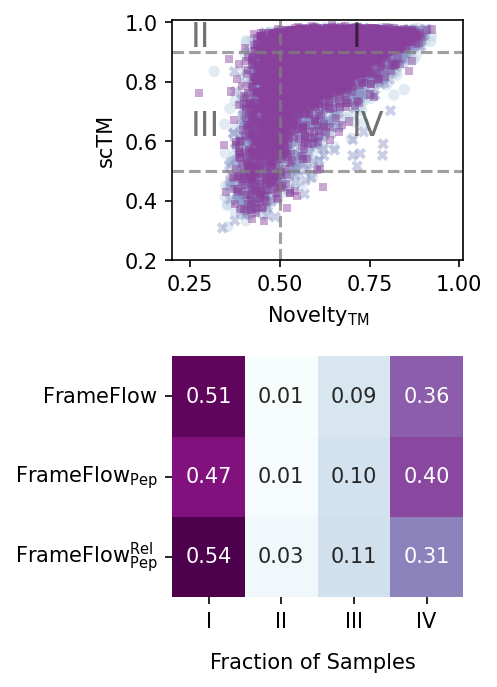

In [12]:
hue = 'Model'

a0 = focus_pdb_metrics_list[focus_pdb_metrics_list['Max TM-score'].gt(0.1)].groupby(hue).size()
a1 = focus_pdb_metrics_list[focus_pdb_metrics_list['Max TM-score'].gt(0.1)].groupby(hue).apply(lambda x: ((x['Max TM-score'] >= 0.5) & (x['max_tm_score'] >= 0.9)).sum())
a2 = focus_pdb_metrics_list[focus_pdb_metrics_list['Max TM-score'].gt(0.1)].groupby(hue).apply(lambda x: ((x['Max TM-score'] < 0.5) & (x['max_tm_score'] >= 0.9)).sum())
a3 = focus_pdb_metrics_list[focus_pdb_metrics_list['Max TM-score'].gt(0.1)].groupby(hue).apply(lambda x: ((x['Max TM-score'] < 0.5) & (x['max_tm_score'] < 0.9) & (x['max_tm_score'] > 0.5)).sum())
a4 = focus_pdb_metrics_list[focus_pdb_metrics_list['Max TM-score'].gt(0.1)].groupby(hue).apply(lambda x: ((x['Max TM-score'] >= 0.5) & (x['max_tm_score'] < 0.9) & (x['max_tm_score'] > 0.5)).sum())

fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(2.5,5),dpi=150) # NOTE: there are some cases where Max TM-score is fill with zero # TODO: fix
g = sns.scatterplot(ax=ax[0], data=focus_pdb_metrics_list[focus_pdb_metrics_list['Max TM-score'].gt(0.1)].sort_values(by=hue), x='Max TM-score', y='max_tm_score', hue=hue, style=hue, linewidth=0, alpha=0.45, s=30, palette='BuPu', legend=0)#legend=1)
g.set_xlim(.2, 1.01)
g.set_ylim(.2, 1.01)
g.set_xlabel(r'$\text{Novelty}_{\text{TM}}$')
g.set_ylabel(r'scTM')

g.axhline(y=0.9, color='gray', alpha=0.75, linestyle='--')
g.axhline(y=0.5, color='gray', alpha=0.75, linestyle='--')
g.axvline(x=0.5, color='gray', alpha=0.75, linestyle='--')

g = sns.heatmap(pd.concat((a1/a0,a2/a0,a3/a0,a4/a0), axis=1).rename(columns={0: 'I', 1: 'II', 2: 'III', 3: 'IV'}), annot=True, cbar=False, cmap='BuPu', ax=ax[1], fmt='.2f')
plt.subplots_adjust(wspace=0.5, hspace=0.4)
g.set_ylabel(None)

ax[0].text(0.7, 0.92, 'I', fontsize=16, alpha=0.55)
ax[0].text(0.25, 0.92, 'II', fontsize=16, alpha=0.55)
ax[0].text(0.25, 0.62, 'III', fontsize=16, alpha=0.55)
ax[0].text(0.7, 0.62, 'IV', fontsize=16, alpha=0.55)
fig.supxlabel('Fraction of Samples', fontsize=10)

plt.show()

In [ ]:
from data.datasets import _process_csv_row_for_global_pep


Path(f'{SOURCE_DIR}/inference_outputs/str_db').mkdir(parents=True, exist_ok=True)

for idx, file in enumerate(focus_pdb_metrics_list.pdb_path.apply(lambda x: Path(f'{SOURCE_DIR}/{x}'))):
    try:
        (Path(f'{SOURCE_DIR}/inference_outputs/str_db/{idx}.pdb')).symlink_to(file)
    except FileExistsError:
        pass

pdb_helix_percent_list, pdb_strand_percent_list, pdb_coil_percent_list = [], [], []

for idx, file in enumerate(ref_df.processed_path):
    file_path = f"../FrameFlowZenodo/{file}"
    data = _process_csv_row_for_global_pep(file_path, return_bb_coords=True)
    bb_coords = data['bb_coords']
    to_write_pdb = f'{SOURCE_DIR}/inference_outputs/str_db/{focus_pdb_metrics_list.shape[0]+idx}.pdb'
    savebb2pdb(['ALA']*bb_coords.shape[0], bb_coords, to_write_pdb)
    
    pdb_helix_percent, pdb_strand_percent, pdb_coil_percent = get_ss_content(to_write_pdb)
    pdb_helix_percent_list.append(pdb_helix_percent)
    pdb_strand_percent_list.append(pdb_strand_percent)
    pdb_coil_percent_list.append(pdb_coil_percent)


ref_df.helix_percent = pdb_helix_percent_list
ref_df.strand_percent = pdb_strand_percent_list
ref_df.coil_percent = pdb_coil_percent_list

In [14]:
# !cd {SOURCE_DIR}/inference_outputs/
# !foldseek createdb str_db str_DB --threads 10
# !foldseek createindex str_DB tmp 
# !foldseek easy-search str_DB str_DB str_db_result tmp/ --alignment-type 1 --exhaustive-search 1 -e 1 --max-seqs 10000 --tmscore-threshold 0.0 --format-mode 4 --format-output query,target,alntmscore,lddt,evalue --threads 64

In [15]:
tm_list = pd.read_csv(f'{SOURCE_DIR}/inference_outputs/str_db_251211_result', sep='\t')
tm_matrix = np.zeros((focus_pdb_metrics_list.shape[0]+ref_df.shape[0],)*2)
for record in tm_list.itertuples():
    tm_matrix[record.query, record.target] = record.evalue
tm_matrix = (tm_matrix + tm_matrix.T)/2 
np.fill_diagonal(tm_matrix, 1)

In [16]:
reducer = umap.UMAP(metric='precomputed', n_neighbors=60, spread=20, min_dist=1)
reduced = reducer.fit_transform(1-tm_matrix)

/home/zhu_zf/miniconda3/envs/fp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zhu_zf/miniconda3/envs/fp/lib/python3.10/site-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
/home/zhu_zf/miniconda3/envs/fp/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/zhu_zf/miniconda3/envs/fp/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [17]:
xmin, xmax, ymin, ymax = reduced[:,0].min(), reduced[:,0].max(), reduced[:,1].min(), reduced[:,1].max()

head_num = focus_pdb_metrics_list.shape[0]
cur_c = get_2d_color(focus_pdb_metrics_list['helix_percent'].tolist()+ref_df['helix_percent'].tolist(), focus_pdb_metrics_list['strand_percent'].tolist()+ref_df['strand_percent'].tolist())
ref_c = cur_c[head_num:]
cur_c = cur_c[:head_num]

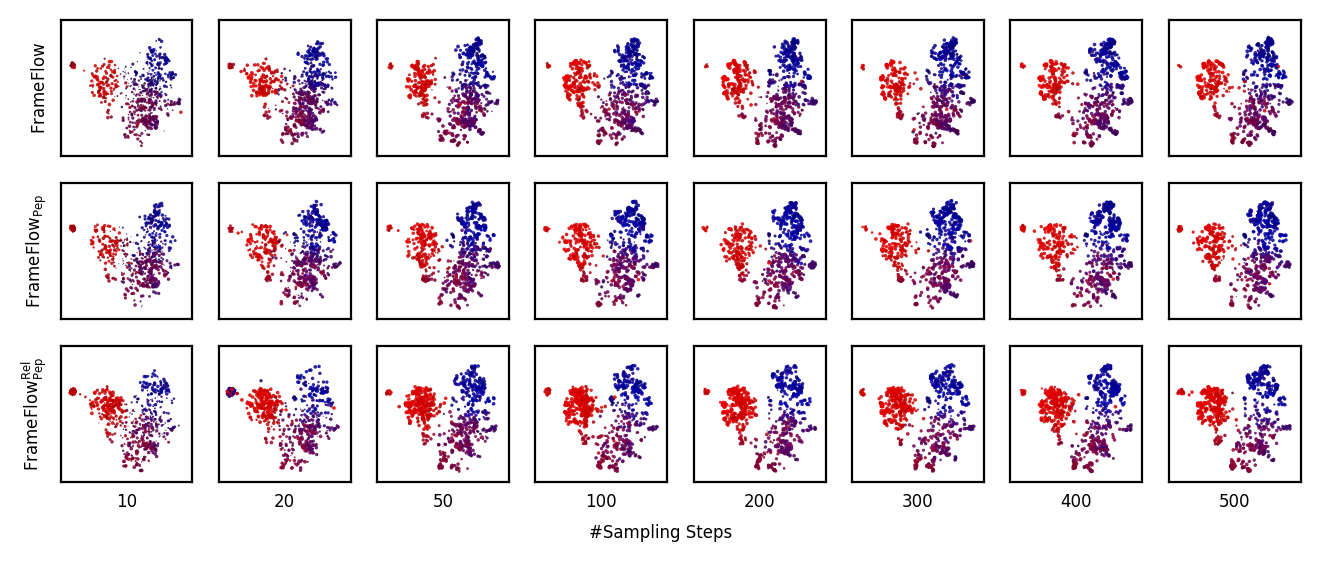

In [18]:
fig, ax = plt.subplots(figsize=(8,3), ncols=8, nrows=3, dpi=200, ) # sharex='col', sharey='row',

ax = ax.flatten()

for idx, (group_name, group_df) in enumerate(focus_pdb_metrics_list.groupby(['Model', 'num_timesteps'], sort=True)):
    g = sns.scatterplot(x=reduced[group_df.index,0], y=reduced[group_df.index,1], linewidth=0, 
                        s=focus_pdb_metrics_list.loc[group_df.index].max_tm_score**3 * 2,
                        alpha=0.85,
                        #alpha=focus_pdb_metrics_list.loc[group_df.index].max_tm_score, 
                        c=cur_c[group_df.index], ax=ax[idx])
    g.set_xticks([])
    g.set_yticks([])
    g.set_xlim(xmin-10, xmax+10)
    g.set_ylim(ymin-10, ymax+10)
    if idx % 8 == 0:
        ax[idx].set_ylabel(group_name[0], rotation=90, fontsize=6)
    if idx >= 16:
        ax[idx].set_xlabel(group_name[1], fontsize=6)

fig.supxlabel("#Sampling Steps", fontsize=6)

plt.show()

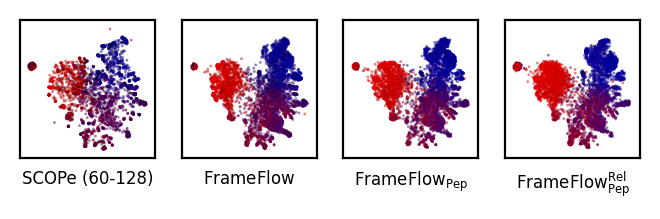

In [19]:
fig, ax = plt.subplots(figsize=(4,0.9), ncols=4, nrows=1, dpi=200, ) # sharex='col', sharey='row',

ax = ax.flatten()

g = sns.scatterplot(x=reduced[head_num:,0], y=reduced[head_num:,1], linewidth=0, alpha=0.5, s=1, c=ref_c, marker='o', ax=ax[0])
g.set_xticks([])
g.set_yticks([])
g.set_xlim(xmin-10, xmax+10)
g.set_ylim(ymin-10, ymax+10)
ax[0].set_xlabel('SCOPe (60-128)', fontsize=6)

for idx, group_name in enumerate(focus_pdb_metrics_list.Model.drop_duplicates()):
    sub_index = focus_pdb_metrics_list.index[focus_pdb_metrics_list.Model.eq(group_name)]
    g = sns.scatterplot(x=reduced[sub_index,0], y=reduced[sub_index,1], linewidth=0, alpha=0.5, s=1, c=cur_c[sub_index], ax=ax[idx+1])
    g.set_xticks([])
    g.set_yticks([])
    g.set_xlim(xmin-10, xmax+10)
    g.set_ylim(ymin-10, ymax+10)
    ax[idx+1].set_xlabel(group_name, fontsize=6)


plt.show()

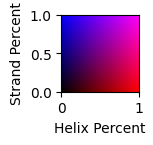

In [20]:
plt.figure(figsize=(1, 1))
plt.imshow(get_2d_color(*(i.ravel() for i in np.meshgrid(np.linspace(0, 1, 256), np.linspace(0, 1, 256)))).reshape((256, 256, 3)), origin='lower', extent=[0, 1, 0, 1], aspect='auto')
plt.xlabel("Helix Percent")
plt.ylabel("Strand Percent")
#plt.title("2D RGB Colormap")
plt.grid(False)
plt.show()